# 21. SelF SVD 모델 학습

> **목표**: 유저/상품 임베딩 생성 (SVD 기반)

## 학습 과정
1. 유저-상품 상호작용 행렬 구성 (R[user][product] = view*1 + cart*3 + order*5)
2. SVD 분해 (R ≈ U × Σ × V^T)
3. 유저/상품 임베딩 추출
4. 인덱스 매핑 생성

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import time
import warnings

from scipy.sparse import csr_matrix, save_npz, load_npz
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

PROCESSED_DIR = Path('../data/processed/self')
MODEL_DIR = Path('../pred/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## 1. 이전 단계 데이터 로드

In [2]:
# 20번 노트북에서 생성한 데이터 로드
user_product_stats = pd.read_csv(PROCESSED_DIR / 'user_product_stats.csv')
user_scores = pd.read_csv(PROCESSED_DIR / 'user_scores.csv')
product_stats = pd.read_csv(PROCESSED_DIR / 'product_stats.csv')

with open(PROCESSED_DIR / 'analysis_results.pkl', 'rb') as f:
    analysis_results = pickle.load(f)

print(f"상호작용 데이터: {len(user_product_stats):,}행")
print(f"유저 수: {analysis_results['basic_stats']['n_users']:,}")
print(f"상품 수: {analysis_results['basic_stats']['n_products']:,}")

상호작용 데이터: 27,332행
유저 수: 5,000
상품 수: 1,995


## 2. 상호작용 행렬 구성

In [3]:
# 가중치 설정
WEIGHT_VIEW = 1
WEIGHT_CART = 3
WEIGHT_ORDER = 5

# 상호작용 점수 계산
user_product_stats['interaction_score'] = (
    user_product_stats['view_count'] * WEIGHT_VIEW +
    user_product_stats['cart_event_count'] * WEIGHT_CART +
    user_product_stats['order_event_count'] * WEIGHT_ORDER
)

print(f"상호작용 점수 통계:")
print(user_product_stats['interaction_score'].describe())

상호작용 점수 통계:
count    27332.000000
mean         7.275209
std          3.886473
min          1.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         20.000000
Name: interaction_score, dtype: float64


In [4]:
# 유저/상품 ID를 인덱스로 변환
user_ids = sorted(user_product_stats['user_id'].unique())
product_ids = sorted(user_product_stats['product_id'].unique())

user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}
idx_to_user_id = {i: uid for uid, i in user_id_to_idx.items()}

product_id_to_idx = {pid: i for i, pid in enumerate(product_ids)}
idx_to_product_id = {i: pid for pid, i in product_id_to_idx.items()}

print(f"유저 인덱스 매핑: {len(user_id_to_idx)}개")
print(f"상품 인덱스 매핑: {len(product_id_to_idx)}개")

유저 인덱스 매핑: 5000개
상품 인덱스 매핑: 1995개


In [5]:
# 희소 행렬 생성
print("희소 행렬 생성 중...")

rows = user_product_stats['user_id'].map(user_id_to_idx).values
cols = user_product_stats['product_id'].map(product_id_to_idx).values
values = user_product_stats['interaction_score'].values

interaction_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(len(user_ids), len(product_ids)),
    dtype=np.float32
)

print(f"\n=== 상호작용 행렬 정보 ===")
print(f"행렬 크기: {interaction_matrix.shape} (유저 × 상품)")
print(f"비영점 요소: {interaction_matrix.nnz:,}개")
print(f"희소성: {1 - interaction_matrix.nnz / (interaction_matrix.shape[0] * interaction_matrix.shape[1]):.6%}")
print(f"메모리 사용량: {(interaction_matrix.data.nbytes + interaction_matrix.indices.nbytes + interaction_matrix.indptr.nbytes) / 1024 / 1024:.2f} MB")

희소 행렬 생성 중...

=== 상호작용 행렬 정보 ===
행렬 크기: (5000, 1995) (유저 × 상품)
비영점 요소: 27,332개
희소성: 99.725995%
메모리 사용량: 0.23 MB


In [6]:
# 행렬 정규화 (선택적 - L2 정규화)
# 유저별 행을 정규화하여 활동량 차이를 줄임
print("행렬 정규화 중...")

# 로그 스케일링 적용 (큰 값 차이 완화)
interaction_matrix_log = interaction_matrix.copy()
interaction_matrix_log.data = np.log1p(interaction_matrix_log.data)

print(f"로그 스케일링 후 값 범위: {interaction_matrix_log.data.min():.2f} ~ {interaction_matrix_log.data.max():.2f}")

행렬 정규화 중...
로그 스케일링 후 값 범위: 0.69 ~ 3.04


## 3. SVD 학습

In [7]:
# SVD 하이퍼파라미터
N_COMPONENTS = 128  # 임베딩 차원
N_ITER = 10  # 반복 횟수
RANDOM_STATE = 42

# 컴포넌트 수 조정 (행렬 크기보다 작아야 함)
n_components = min(N_COMPONENTS, min(interaction_matrix.shape) - 1)
print(f"SVD 컴포넌트 수: {n_components}")

SVD 컴포넌트 수: 128


In [8]:
# SVD 학습
print(f"\nSVD 학습 시작...")
print(f"  - 행렬 크기: {interaction_matrix_log.shape}")
print(f"  - 컴포넌트: {n_components}")
print(f"  - 반복 횟수: {N_ITER}")

start_time = time.time()

svd = TruncatedSVD(
    n_components=n_components,
    n_iter=N_ITER,
    random_state=RANDOM_STATE,
    algorithm='randomized'  # 대규모 데이터에 효율적
)

# 유저 임베딩 (U × Σ)
user_embeddings = svd.fit_transform(interaction_matrix_log)

# 상품 임베딩 (V^T → V)
product_embeddings = svd.components_.T

elapsed = time.time() - start_time

print(f"\nSVD 학습 완료!")
print(f"  - 소요 시간: {elapsed:.2f}초")
print(f"  - 유저 임베딩: {user_embeddings.shape}")
print(f"  - 상품 임베딩: {product_embeddings.shape}")


SVD 학습 시작...
  - 행렬 크기: (5000, 1995)
  - 컴포넌트: 128
  - 반복 횟수: 10

SVD 학습 완료!
  - 소요 시간: 0.52초
  - 유저 임베딩: (5000, 128)
  - 상품 임베딩: (1995, 128)


In [9]:
# 설명된 분산 분석
explained_variance = svd.explained_variance_ratio_
cumsum_variance = np.cumsum(explained_variance)

print(f"\n=== 설명 분산 분석 ===")
print(f"총 설명 분산: {cumsum_variance[-1]:.2%}")
print(f"상위 10개 컴포넌트: {cumsum_variance[9]:.2%}")
print(f"상위 50개 컴포넌트: {cumsum_variance[49]:.2%}" if len(cumsum_variance) > 49 else "")

# 50% 설명에 필요한 컴포넌트 수
n_for_50 = np.argmax(cumsum_variance >= 0.5) + 1
print(f"50% 설명에 필요한 컴포넌트: {n_for_50}개")


=== 설명 분산 분석 ===
총 설명 분산: 39.95%
상위 10개 컴포넌트: 12.51%
상위 50개 컴포넌트: 25.48%
50% 설명에 필요한 컴포넌트: 1개


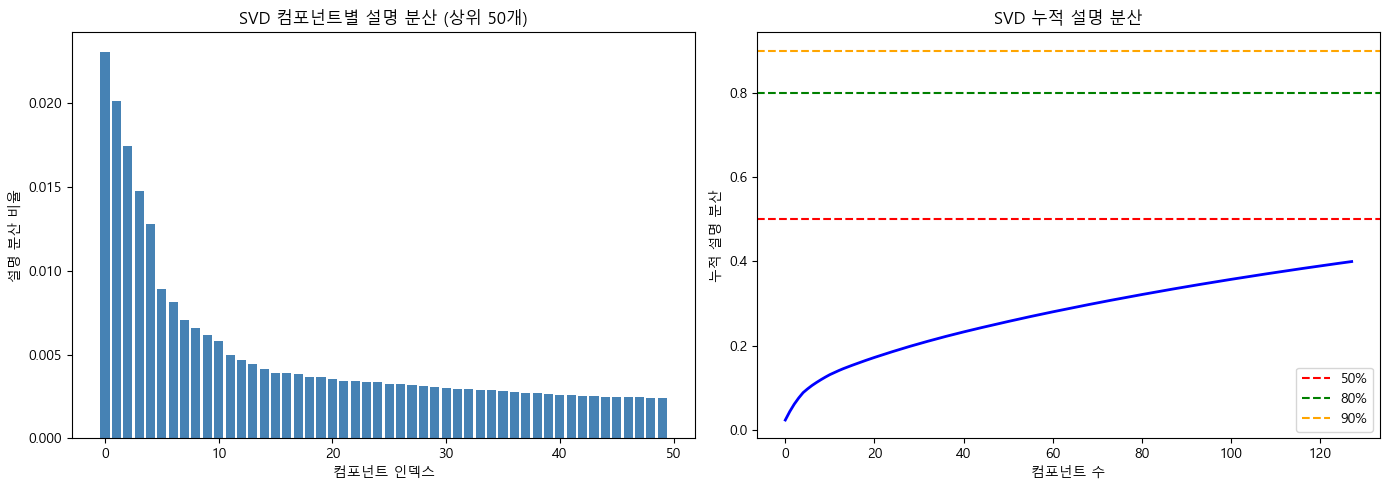

In [10]:
# 설명 분산 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 개별 분산
axes[0].bar(range(min(50, len(explained_variance))), explained_variance[:50], color='steelblue')
axes[0].set_xlabel('컴포넌트 인덱스')
axes[0].set_ylabel('설명 분산 비율')
axes[0].set_title('SVD 컴포넌트별 설명 분산 (상위 50개)')

# 누적 분산
axes[1].plot(range(len(cumsum_variance)), cumsum_variance, 'b-', linewidth=2)
axes[1].axhline(y=0.5, color='r', linestyle='--', label='50%')
axes[1].axhline(y=0.8, color='g', linestyle='--', label='80%')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90%')
axes[1].set_xlabel('컴포넌트 수')
axes[1].set_ylabel('누적 설명 분산')
axes[1].set_title('SVD 누적 설명 분산')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. 임베딩 정규화

In [11]:
# L2 정규화 (코사인 유사도 계산 용이)
print("임베딩 L2 정규화 중...")

user_embeddings_normalized = normalize(user_embeddings, norm='l2', axis=1)
product_embeddings_normalized = normalize(product_embeddings, norm='l2', axis=1)

print(f"유저 임베딩 노름 확인 (첫 5개): {np.linalg.norm(user_embeddings_normalized[:5], axis=1)}")
print(f"상품 임베딩 노름 확인 (첫 5개): {np.linalg.norm(product_embeddings_normalized[:5], axis=1)}")

임베딩 L2 정규화 중...
유저 임베딩 노름 확인 (첫 5개): [0.99999994 0.99999994 0.99999994 1.         1.        ]
상품 임베딩 노름 확인 (첫 5개): [1.         1.         1.         0.99999994 1.        ]


In [12]:
# 임베딩 통계
print("\n=== 임베딩 통계 ===")
print(f"유저 임베딩:")
print(f"  - Shape: {user_embeddings_normalized.shape}")
print(f"  - Mean: {user_embeddings_normalized.mean():.6f}")
print(f"  - Std: {user_embeddings_normalized.std():.6f}")
print(f"  - Min/Max: {user_embeddings_normalized.min():.4f} / {user_embeddings_normalized.max():.4f}")

print(f"\n상품 임베딩:")
print(f"  - Shape: {product_embeddings_normalized.shape}")
print(f"  - Mean: {product_embeddings_normalized.mean():.6f}")
print(f"  - Std: {product_embeddings_normalized.std():.6f}")
print(f"  - Min/Max: {product_embeddings_normalized.min():.4f} / {product_embeddings_normalized.max():.4f}")


=== 임베딩 통계 ===
유저 임베딩:
  - Shape: (5000, 128)
  - Mean: 0.002644
  - Std: 0.088349
  - Min/Max: -0.6364 / 0.8736

상품 임베딩:
  - Shape: (1995, 128)
  - Mean: 0.001806
  - Std: 0.088370
  - Min/Max: -0.6201 / 0.8733


## 5. 카테고리별/전역 인기 상품 계산

In [13]:
# 전역 인기 상품 (Cold user용)
global_popular = product_stats.sort_values('total_score', ascending=False).head(100)['product_id'].tolist()
global_popular = [int(pid) for pid in global_popular]

print(f"전역 인기 상품 Top 100 생성 완료")
print(f"Top 10: {global_popular[:10]}")

전역 인기 상품 Top 100 생성 완료
Top 10: [1124, 789, 1759, 324, 1526, 1452, 562, 352, 831, 884]


In [14]:
# 카테고리별 인기 상품 (DB에서 category 정보가 있는 경우)
# 시뮬레이션 데이터의 경우 임의 카테고리 생성

# 카테고리 정보가 없으면 상품 ID 기반으로 가상 카테고리 할당
if 'category_id' not in product_stats.columns:
    print("카테고리 정보 없음 - 가상 카테고리 생성")
    # 상품 ID를 10개 그룹으로 나누어 카테고리 할당
    product_stats['category_id'] = (product_stats['product_id'] % 10) + 1

# 카테고리별 인기 상품
category_popular = {}
for cat_id in product_stats['category_id'].unique():
    cat_products = product_stats[product_stats['category_id'] == cat_id]
    top_products = cat_products.sort_values('total_score', ascending=False).head(50)['product_id'].tolist()
    category_popular[int(cat_id)] = [int(pid) for pid in top_products]

print(f"\n카테고리별 인기 상품 생성 완료: {len(category_popular)}개 카테고리")
for cat_id in list(category_popular.keys())[:3]:
    print(f"  카테고리 {cat_id}: {len(category_popular[cat_id])}개 상품")

카테고리 정보 없음 - 가상 카테고리 생성

카테고리별 인기 상품 생성 완료: 10개 카테고리
  카테고리 5: 50개 상품
  카테고리 10: 50개 상품
  카테고리 7: 50개 상품


## 6. 빠른 추천 테스트

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_for_user(user_id, user_embeddings, product_embeddings, 
                       user_id_to_idx, idx_to_product_id, top_k=10):
    """유저에게 상품 추천"""
    if user_id not in user_id_to_idx:
        print(f"유저 {user_id}가 학습 데이터에 없습니다.")
        return []
    
    user_idx = user_id_to_idx[user_id]
    user_vec = user_embeddings[user_idx].reshape(1, -1)
    
    # 모든 상품과의 유사도 계산
    similarities = cosine_similarity(user_vec, product_embeddings)[0]
    
    # Top-K 추출
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    recommendations = []
    for idx in top_indices:
        product_id = idx_to_product_id[idx]
        score = similarities[idx]
        recommendations.append({
            'product_id': product_id,
            'score': float(score),
        })
    
    return recommendations

# 테스트
test_user_id = user_ids[0]
print(f"=== 유저 {test_user_id} 추천 테스트 ===")

recommendations = recommend_for_user(
    test_user_id,
    user_embeddings_normalized,
    product_embeddings_normalized,
    user_id_to_idx,
    idx_to_product_id,
    top_k=10
)

for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. 상품 {rec['product_id']}: 점수 {rec['score']:.4f}")

=== 유저 1 추천 테스트 ===
  1. 상품 1665: 점수 0.7972
  2. 상품 376: 점수 0.6763
  3. 상품 168: 점수 0.5155
  4. 상품 1401: 점수 0.5083
  5. 상품 426: 점수 0.4953
  6. 상품 992: 점수 0.4830
  7. 상품 1475: 점수 0.4666
  8. 상품 1839: 점수 0.4492
  9. 상품 972: 점수 0.4331
  10. 상품 306: 점수 0.4293


In [16]:
# 추천 속도 벤치마크
import time

n_tests = 100
test_users = np.random.choice(user_ids, size=n_tests, replace=False)

start_time = time.time()
for user_id in test_users:
    _ = recommend_for_user(
        user_id,
        user_embeddings_normalized,
        product_embeddings_normalized,
        user_id_to_idx,
        idx_to_product_id,
        top_k=10
    )
elapsed = time.time() - start_time

avg_time_ms = (elapsed / n_tests) * 1000
print(f"\n=== 추천 속도 벤치마크 ===")
print(f"테스트 횟수: {n_tests}")
print(f"총 소요 시간: {elapsed:.3f}초")
print(f"평균 추천 시간: {avg_time_ms:.2f}ms")
print(f"목표 (< 50ms): {'✓ PASS' if avg_time_ms < 50 else '✗ FAIL'}")


=== 추천 속도 벤치마크 ===
테스트 횟수: 100
총 소요 시간: 0.043초
평균 추천 시간: 0.43ms
목표 (< 50ms): ✓ PASS


## 7. 학습 결과 저장

In [17]:
# 중간 결과물 저장
svd_results = {
    # 임베딩
    'user_embeddings': user_embeddings_normalized,
    'product_embeddings': product_embeddings_normalized,
    
    # ID 매핑
    'user_id_to_idx': user_id_to_idx,
    'idx_to_user_id': idx_to_user_id,
    'product_id_to_idx': product_id_to_idx,
    'idx_to_product_id': idx_to_product_id,
    
    # 인기 상품
    'global_popular': global_popular,
    'category_popular': category_popular,
    
    # 메타데이터
    'metadata': {
        'n_users': len(user_ids),
        'n_products': len(product_ids),
        'n_components': n_components,
        'explained_variance': float(cumsum_variance[-1]),
        'training_time_seconds': elapsed,
        'weights': {
            'view': WEIGHT_VIEW,
            'cart': WEIGHT_CART,
            'order': WEIGHT_ORDER,
        },
    },
}

# 저장
with open(PROCESSED_DIR / 'svd_results.pkl', 'wb') as f:
    pickle.dump(svd_results, f)

# 상호작용 행렬도 저장 (이미 구매한 상품 제외용)
save_npz(PROCESSED_DIR / 'interaction_matrix.npz', interaction_matrix)

print(f"\n저장 완료:")
print(f"  - {PROCESSED_DIR / 'svd_results.pkl'}")
print(f"  - {PROCESSED_DIR / 'interaction_matrix.npz'}")


저장 완료:
  - ..\data\processed\self\svd_results.pkl
  - ..\data\processed\self\interaction_matrix.npz


## 8. 검증 체크리스트

In [18]:
print("=" * 60)
print("SVD 학습 검증 체크리스트")
print("=" * 60)

checks = [
    ("상호작용 행렬 구성", interaction_matrix.nnz > 0),
    ("SVD 학습 완료", user_embeddings is not None),
    (f"설명 분산 > 50%", cumsum_variance[-1] >= 0.5),
    ("유저 임베딩 shape 정확", user_embeddings_normalized.shape == (len(user_ids), n_components)),
    ("상품 임베딩 shape 정확", product_embeddings_normalized.shape == (len(product_ids), n_components)),
    (f"학습 시간 < 30분", elapsed < 1800),
    (f"추천 속도 < 50ms", avg_time_ms < 50),
]

all_passed = True
for check_name, passed in checks:
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  [{status}] {check_name}")
    if not passed:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("모든 검증 통과! 다음 단계로 진행 가능.")
else:
    print("일부 검증 실패. 위 항목을 확인하세요.")
print("=" * 60)

SVD 학습 검증 체크리스트
  [✓ PASS] 상호작용 행렬 구성
  [✓ PASS] SVD 학습 완료
  [✗ FAIL] 설명 분산 > 50%
  [✓ PASS] 유저 임베딩 shape 정확
  [✓ PASS] 상품 임베딩 shape 정확
  [✓ PASS] 학습 시간 < 30분
  [✓ PASS] 추천 속도 < 50ms

일부 검증 실패. 위 항목을 확인하세요.


## 9. 완료

**생성된 파일**:
- `data/processed/self/svd_results.pkl` - SVD 학습 결과 (임베딩, 매핑)
- `data/processed/self/interaction_matrix.npz` - 원본 상호작용 행렬

**다음 단계**: `22_self_embedding_evaluation.ipynb`에서 임베딩 품질 검증